In [ ]:
# Local fallback for environments without SciPy.
# This cell is added only to the validated composite notebook.
try:
    from scipy.stats import norm as _scipy_norm_check
except Exception:
    import sys
    import types
    from statistics import NormalDist

    class _Norm:
        def __init__(self):
            self._dist = NormalDist()
        def ppf(self, q):
            return self._dist.inv_cdf(q)

    stats_mod = types.ModuleType("scipy.stats")
    stats_mod.norm = _Norm()
    scipy_mod = types.ModuleType("scipy")
    scipy_mod.stats = stats_mod
    sys.modules["scipy"] = scipy_mod
    sys.modules["scipy.stats"] = stats_mod
    print("SciPy not available; installed a local scipy.stats.norm.ppf fallback for this notebook.")


# Week 15-1 · PRM-01 — Portfolio &amp; Risk Management for Algorithmic Trading (Part I)

**Instructor: Rishabh Patankar** (QuantInsti). A theory-heavy first session on the **risk management
process**, real-world **blow-up case studies**, and the **algorithmic-trading-specific risks** you
must catch *before* an order ever reaches the exchange. The lecture ships no data or code — this
notebook turns every quantitative idea in it into runnable Python so you can *feel* the numbers.

**The five-phase risk process (the spine of the whole lecture):**

| Phase | What you do |
|---|---|
| 1 · Structure &amp; policy | A **dedicated risk department**, walled off from trading, with veto power |
| 2 · Identify sources | market · credit/counterparty · financial · operational · liquidity · disaster |
| 3 · Evaluate / quantify | Greeks · what-if grids · **VaR / CVaR** · stress tests · **PD × LGD** |
| 4 · Set limits | cash · geography · sector · settlement · order/day · access control |
| 5 · Design controls | centralized, real-time monitoring that reacts faster than a human can |

The thread Rishabh repeats: *"we don't want to make all the mistakes ourselves"* — so we learn from
**Kerviel, Adoboli, LTCM, Knight Capital, Credit Suisse, Hanmax, Porsche/VW**, and build the checks
that would have stopped each one.

In [1]:
import numpy as np
import pandas as pd
import hashlib, time
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
print("ready")

ready


## Phase 2-3 · Market risk — the building blocks

### Value at Risk (VaR) three ways
Rishabh's definition: take a portfolio, look at the distribution of possible outcomes, and read off
the **5th-percentile** loss. *"An 8% chance the asset declines 2% over one month"* is a VaR statement.
Three standard methods: **historical**, **parametric (variance–covariance)**, and **Monte Carlo**.

In [2]:
# A representative $1,000,000 portfolio of daily returns (mean ~0, ~1.5% daily vol).
rng = np.random.default_rng(151)
PV = 1_000_000
rets = rng.normal(0.0003, 0.015, 2000)        # ~8 years of daily returns
alpha = 0.05                                   # 95% confidence -> 5th percentile

# (1) HISTORICAL VaR: empirical 5th percentile of actual returns
var_hist = -np.percentile(rets, alpha*100) * PV
# (2) PARAMETRIC (variance-covariance): assume normal, z(5%) = -1.645
from scipy.stats import norm
z = norm.ppf(alpha)
var_param = -(rets.mean() + z*rets.std()) * PV
# (3) MONTE CARLO: simulate from the fitted normal
sim = rng.normal(rets.mean(), rets.std(), 200_000)
var_mc = -np.percentile(sim, alpha*100) * PV
print(f"1-day 95% VaR on a ${PV:,} portfolio:")
print(f"  Historical   : ${var_hist:,.0f}")
print(f"  Parametric   : ${var_param:,.0f}")
print(f"  Monte Carlo  : ${var_mc:,.0f}")
print("Reading: 'with 95% confidence we won't lose more than this in a day' (5% of days we might).")

1-day 95% VaR on a $1,000,000 portfolio:
  Historical   : $24,957
  Parametric   : $25,252
  Monte Carlo  : $25,270
Reading: 'with 95% confidence we won't lose more than this in a day' (5% of days we might).


### CVaR (Conditional VaR / Expected Shortfall) — beyond the cliff edge
A student asks about CVaR. VaR tells you the threshold of the worst 5% of days; **CVaR tells you the
*average* loss once you're in that tail** — it captures fat-tail / black-swan severity that VaR
ignores.

In [3]:
# CVaR = mean loss in the worst alpha% of outcomes (the tail VaR doesn't describe)
losses = -rets * PV
cutoff = np.percentile(losses, (1-alpha)*100)   # the VaR loss level
cvar = losses[losses >= cutoff].mean()
print(f"95% VaR  (threshold of worst 5%) : ${var_hist:,.0f}")
print(f"95% CVaR (AVERAGE of worst 5%)   : ${cvar:,.0f}")
print(f"CVaR is {cvar/var_hist:.2f}x the VaR -> the tail is worse than the threshold suggests.")

95% VaR  (threshold of worst 5%) : $24,957
95% CVaR (AVERAGE of worst 5%)   : $31,612
CVaR is 1.27x the VaR -> the tail is worse than the threshold suggests.


### Stress testing — replay the black swans
Instead of a statistical tail, *replay history*. Apply the actual shocks of past crises to today's
portfolio and see what survives.

In [4]:
# Apply named historical shocks to the $1m portfolio (representative one-day/episode moves).
stress = {
    "2008 GFC (housing collapse)": -0.20,
    "2011 Eurozone crisis":        -0.12,
    "2020 COVID crash":            -0.30,
    "2022 Russia-Ukraine":         -0.08,
    "2025 tariff shock":           -0.06,
}
tbl = pd.DataFrame({
    "shock %": [f"{v*100:.0f}%" for v in stress.values()],
    "P&L ($)": [f"{v*PV:,.0f}" for v in stress.values()],
}, index=stress.keys())
print(tbl.to_string())
print("\nStress tests reveal what a VaR built on calm data never will: black-swan survivability.")

                            shock %   P&L ($)
2008 GFC (housing collapse)    -20%  -200,000
2011 Eurozone crisis           -12%  -120,000
2020 COVID crash               -30%  -300,000
2022 Russia-Ukraine             -8%   -80,000
2025 tariff shock               -6%   -60,000

Stress tests reveal what a VaR built on calm data never will: black-swan survivability.


### Dividend risk &amp; currency risk — two subtle market exposures
**Dividend:** when a stock pays a ₹10 dividend the price drops ~₹10 next day — but a *shareholder* is
whole (price + dividend). A **call-option holder gets no dividend**, so the same drop can push the
option out-of-the-money. **Currency:** an Indian investor long Tesla can profit (or lose) purely from
USD/INR moving, even if Tesla itself never moves.

In [5]:
# Dividend: shareholder neutral, call holder hurt
S0, div = 100.0, 10.0
S_ex = S0 - div
print("DIVIDEND RISK")
print(f"  Shareholder: price {S0}->{S_ex} but +{div} cash = {S_ex+div} (neutral)")
print(f"  Call holder (strike 100): stock {S0}->{S_ex} = now OUT of the money, no dividend (hurt)\n")

# Currency: Tesla flat, USD/INR moves -> INR P&L appears from nothing
shares, tsla = 10, 84.0
fx0, fx1 = 84.0, 90.0
pnl_inr = shares*tsla*(fx1-fx0)
print("CURRENCY RISK (Indian investor long Tesla)")
print(f"  Tesla flat at ${tsla}, USD/INR {fx0}->{fx1}")
print(f"  INR P&L from FX alone = {shares}*{tsla}*({fx1}-{fx0}) = Rs {pnl_inr:,.0f}")

DIVIDEND RISK
  Shareholder: price 100.0->90.0 but +10.0 cash = 100.0 (neutral)
  Call holder (strike 100): stock 100.0->90.0 = now OUT of the money, no dividend (hurt)

CURRENCY RISK (Indian investor long Tesla)
  Tesla flat at $84.0, USD/INR 84.0->90.0
  INR P&L from FX alone = 10*84.0*(90.0-84.0) = Rs 5,040


### The what-if grid — portfolio value vs two factors
Rishabh's spreadsheet trick: tabulate portfolio value across a grid of **price change × implied-vol
change**. Modern tooling lets you extend it to Greeks, rates, FX, tariffs — any factor.

In [6]:
# What-if: portfolio value (base 100) under price shocks x IV shocks (toy sensitivities)
price_shocks = np.array([-0.10, -0.05, 0.0, 0.05, 0.10])
iv_shocks    = np.array([-0.20, -0.10, 0.0, 0.10, 0.20])
base = 100.0
# crude: value reacts +0.8 per unit price move, +0.1 per unit IV move (a long-vol-ish book)
grid = base*(1 + 0.8*price_shocks[:,None] + 0.1*iv_shocks[None,:])
whatif = pd.DataFrame(grid.round(1),
    index=[f"price {int(p*100):+d}%" for p in price_shocks],
    columns=[f"IV {int(v*100):+d}%" for v in iv_shocks])
print(whatif.to_string())

            IV -20%  IV -10%  IV +0%  IV +10%  IV +20%
price -10%     90.0     91.0    92.0     93.0     94.0
price -5%      94.0     95.0    96.0     97.0     98.0
price +0%      98.0     99.0   100.0    101.0    102.0
price +5%     102.0    103.0   104.0    105.0    106.0
price +10%    106.0    107.0   108.0    109.0    110.0


## Phase 3 · Credit &amp; counterparty risk — expected loss

Banks quantify credit risk with the Basel **IRB** approach. The core formula every quant should know:

$$\text{Expected Loss} = PD \times LGD \times EAD$$

(probability of default × loss given default × exposure at default). Losses split into **expected**
(price it in), **unexpected** (hold capital), and **stress** (too rare/expensive to fully hedge).

In [7]:
# Expected loss for a book of counterparties
book = pd.DataFrame({
    "counterparty": ["Broker A", "Broker B", "Clearing house", "Hedge-fund client"],
    "EAD":          [2_000_000, 500_000, 5_000_000, 1_200_000],   # exposure at default
    "PD":           [0.02, 0.08, 0.001, 0.05],                    # prob of default
    "LGD":          [0.45, 0.60, 0.30, 0.55],                     # loss given default
})
book["expected_loss"] = book.EAD * book.PD * book.LGD
print(book.to_string(index=False))
print(f"\nTotal expected loss to provision for: ${book.expected_loss.sum():,.0f}")
print("LTCM lesson: even Nobel laureates (Scholes/Merton) blew up - leveraged bond arb + Russian")
print("default 1998 = financial risk + liquidity risk together; needed a Fed-organized bailout.")

     counterparty     EAD    PD  LGD  expected_loss
         Broker A 2000000 0.020 0.45        18000.0
         Broker B  500000 0.080 0.60        24000.0
   Clearing house 5000000 0.001 0.30         1500.0
Hedge-fund client 1200000 0.050 0.55        33000.0

Total expected loss to provision for: $76,500
LTCM lesson: even Nobel laureates (Scholes/Merton) blew up - leveraged bond arb + Russian
default 1998 = financial risk + liquidity risk together; needed a Fed-organized bailout.


## Phase 4 · Setting risk limits — geography example

Limits cap exposure by cash, **geography**, sector, asset class, and counterparty. Rishabh's ABC
example: a tariff on one region hits revenue concentrated there.

In [8]:
# Company ABC revenue by region; a US tariff shock hits the US-exposed slice.
abc = pd.DataFrame({"region": ["US","Europe","Asia-Pacific"], "rev_share": [0.50, 0.30, 0.20]})
tariff = 0.30   # assume a 30% effective revenue hit on the US-exposed portion
abc["rev_hit"] = np.where(abc.region=="US", -abc.rev_share*tariff, 0.0)
print(abc.to_string(index=False))
print(f"Total revenue impact from a US tariff: {abc.rev_hit.sum()*100:.1f}%")
# A risk-limit policy then caps geography exposure, e.g. 30% US / 30% EU / 40% rest
limits = {"US": 0.30, "Europe": 0.30, "Rest of world": 0.40}
print("\nGeography risk limits:", limits, "-> diversify so no single tariff/regulation dominates.")

      region  rev_share  rev_hit
          US        0.5    -0.15
      Europe        0.3     0.00
Asia-Pacific        0.2     0.00
Total revenue impact from a US tariff: -15.0%

Geography risk limits: {'US': 0.3, 'Europe': 0.3, 'Rest of world': 0.4} -> diversify so no single tariff/regulation dominates.


### Futures-vs-cash settlement mismatch
A hedged book can be *profitable on paper* yet forced to unwind. **Futures mark-to-market daily** (a
loss is debited tonight); **option profit is only realized at exercise/expiry**. So a hedge that's
net flat can still trigger a **daily cash call** on the futures leg.

In [9]:
# Hedged position: option profit (unrealized) vs futures loss (cash TODAY)
option_pnl_unrealized = +5000   # in-the-money but not yet exercised -> no cash yet
futures_pnl_realized  = -5000   # marked-to-market -> cash leaves the account TONIGHT
print(f"Option leg : +${option_pnl_unrealized:,} (paper, arrives at expiry)")
print(f"Futures leg: ${futures_pnl_realized:,} (CASH debited tonight via MtM)")
print("Net economic P&L = $0, but you owe $5,000 cash now -> margin call -> may be forced to unwind")
print("the winning option leg to fund the futures variation margin. Settlement-type limits prevent this.")

Option leg : +$5,000 (paper, arrives at expiry)
Futures leg: $-5,000 (CASH debited tonight via MtM)
Net economic P&L = $0, but you owe $5,000 cash now -> margin call -> may be forced to unwind
the winning option leg to fund the futures variation margin. Settlement-type limits prevent this.


## Algo-trading incidents — and the check that would have stopped each

These are the heart of the lecture. Each disaster maps to a control you can code.

In [10]:
incidents = pd.DataFrame({
 "incident": ["Kerviel / SocGen 2008","Adoboli / UBS 2011","Credit Suisse 2007","Infinium Capital",
              "Deutsche Bank Tokyo","Knight Capital 2012","Goldman Sachs","Hanmax Securities",
              "Everbright"],
 "loss": ["EUR4.9bn","$2.2bn","$150k","$850k","mkt -1%","$460M+$12M fine","$100M","KRW57bn","banned"],
 "root cause": ["back-office knowledge hid trades","false trades, no leave",
                "removed OK button -> arrow re-fires orders","ETF priced futures; fair value jumped",
                "broken price feed + offset","1/8 servers ran 8-yr-old code","IOIs sent as live orders",
                "read calls as puts","rogue algo bubble, then shorted it (insider trading)"],
 "control": ["independent risk dept + mandatory leave","team rotation, 2-wk leave, PnL recon",
             "confirmation / order-throttle","liquidity-aware fair value + order limit",
             "stale-data timestamp + heartbeat","MD5 checksum + version check",
             "order-type validation","call/put validation","PnL spike + regulator reporting"],
})
print(incidents.to_string(index=False))

             incident            loss                                           root cause                                  control
Kerviel / SocGen 2008        EUR4.9bn                     back-office knowledge hid trades  independent risk dept + mandatory leave
   Adoboli / UBS 2011          $2.2bn                               false trades, no leave     team rotation, 2-wk leave, PnL recon
   Credit Suisse 2007           $150k           removed OK button -> arrow re-fires orders            confirmation / order-throttle
     Infinium Capital           $850k                ETF priced futures; fair value jumped liquidity-aware fair value + order limit
  Deutsche Bank Tokyo         mkt -1%                           broken price feed + offset         stale-data timestamp + heartbeat
  Knight Capital 2012 $460M+$12M fine                        1/8 servers ran 8-yr-old code             MD5 checksum + version check
        Goldman Sachs           $100M                             IOIs sent 

### The Knight Capital fix — verify the binary with a checksum
Knight lost \$460M because **one of eight servers ran 8-year-old code**. Three cheap checks catch it:
**file size**, **last-modified date**, and an **MD5 checksum** (a fingerprint of every byte).

In [11]:
# Two 'deployments' of the same program; one server got stale bytes -> different MD5.
good_binary = b"strategy_v10_correct_bytes_for_all_servers"
stale_binary = b"strategy_v2_eight_year_old_bytes!!!!!!!!!!!"
def md5(b): return hashlib.md5(b).hexdigest()
golden = md5(good_binary)
servers = {f"server{i}": good_binary for i in range(1, 8)}
servers["server8"] = stale_binary    # the one technician who didn't update
print(f"golden MD5 = {golden}\n")
for name, b in servers.items():
    h = md5(b); ok = (h == golden)
    print(f"  {name}: {h[:12]}... {'OK' if ok else '*** STALE -> HALT DEPLOY ***'}")

golden MD5 = 3ec5b580a39991283ae1754604fee8e2

  server1: 3ec5b580a399... OK
  server2: 3ec5b580a399... OK
  server3: 3ec5b580a399... OK
  server4: 3ec5b580a399... OK
  server5: 3ec5b580a399... OK
  server6: 3ec5b580a399... OK
  server7: 3ec5b580a399... OK
  server8: 61adcbd74e5b... *** STALE -> HALT DEPLOY ***


## Phase 5 · Algo-specific risk controls (before the order leaves the app)

These live *inside* your system, between market data and the order gateway: **access**,
**consistency**, **quality**, **algorithm**, **technology**, **scalability**.

In [12]:
# ACCESS: heartbeat to detect a dead connection to the exchange
def heartbeat_ok(last_pong_ts, now_ts, max_gap=2.0):
    return (now_ts - last_pong_ts) <= max_gap
now = 100.0
print("ACCESS - heartbeat:")
print(f"  pong 1.0s ago -> {'alive' if heartbeat_ok(99.0, now) else 'DEAD'}")
print(f"  pong 5.0s ago -> {'alive' if heartbeat_ok(95.0, now) else 'DEAD (halt, reconnect)'}")

# CONSISTENCY: reject stale market data via timestamp threshold
def data_fresh(data_ts, clock_ts, max_lag=1.0):
    return (clock_ts - data_ts) <= max_lag
print("\nCONSISTENCY - stale-data check:")
print(f"  data 0.3s old -> {'use' if data_fresh(99.7, now) else 'discard'}")
print(f"  data 5.0s old -> {'use' if data_fresh(95.0, now) else 'DISCARD (stale)'}")

ACCESS - heartbeat:
  pong 1.0s ago -> alive
  pong 5.0s ago -> DEAD (halt, reconnect)

CONSISTENCY - stale-data check:
  data 0.3s old -> use
  data 5.0s old -> DISCARD (stale)


In [13]:
# QUALITY: garbled book where ask < bid must be discarded
def book_sane(bid, ask): return ask > bid
print("QUALITY - garbled-book check:")
print(f"  bid 149.95 / ask 150.00 -> {'OK' if book_sane(149.95,150.00) else 'discard'}")
print(f"  bid 150.00 / ask 149.00 -> {'OK' if book_sane(150.00,149.00) else 'DISCARD (ask<bid)'}")

# ALGORITHM: fat-finger / price-range check (order price within 5% of last)
def price_range_ok(order_px, last_px, band=0.05):
    return abs(order_px/last_px - 1) <= band
print("\nALGORITHM - price-range / fat-finger check (5% band):")
print(f"  order 102 vs last 100 -> {'send' if price_range_ok(102,100) else 'reject'}")
print(f"  order 130 vs last 100 -> {'send' if price_range_ok(130,100) else 'REJECT (fat finger?)'}")

QUALITY - garbled-book check:
  bid 149.95 / ask 150.00 -> OK
  bid 150.00 / ask 149.00 -> DISCARD (ask<bid)

ALGORITHM - price-range / fat-finger check (5% band):
  order 102 vs last 100 -> send
  order 130 vs last 100 -> REJECT (fat finger?)


### The tick-by-tick order-limit trap
Rishabh's key coding lesson: a naive `if price(A)==100: order 10 of B` works on daily data but
**explodes on tick data** — you fire orders faster than fills confirm. The fix is to gate on
**orders already placed + orders still in flight** against a threshold.

In [14]:
# Simulate fast ticks; naive rule over-sends, gated rule respects the limit.
MAX_ORDERS = 5
ticks_A = [100, 100, 100, 100, 100, 100, 100, 100]   # A keeps printing the trigger price

# NAIVE: fires on every qualifying tick (confirmations lag) -> way over the limit
naive_orders = sum(1 for p in ticks_A if p == 100)

# GATED: count placed + in-flight; stop at MAX_ORDERS
placed = 0; in_flight = 0
for p in ticks_A:
    if p == 100 and (placed + in_flight) < MAX_ORDERS:
        in_flight += 1                 # sent, awaiting ack
        if in_flight >= 2:             # some acks arrive
            placed += 1; in_flight -= 1
gated_orders = placed + in_flight
print(f"Naive rule  -> {naive_orders} orders sent (BREACHES limit of {MAX_ORDERS})")
print(f"Gated rule  -> {gated_orders} orders (placed+in-flight capped at {MAX_ORDERS})")
print("Always gate on placed + in-flight, not just the price condition.")

Naive rule  -> 8 orders sent (BREACHES limit of 5)
Gated rule  -> 5 orders (placed+in-flight capped at 5)
Always gate on placed + in-flight, not just the price condition.


In [15]:
# PnL FLUCTUATION + 'too good to be true' check
def pnl_alert(pct_change, band=0.10):
    return abs(pct_change) >= band
print("PnL fluctuation check (+/-10% intraday = investigate):")
for ch in [0.03, 0.12, -0.15]:
    print(f"  {ch*100:+.0f}% -> {'ALERT (system or strategy error?)' if pnl_alert(ch) else 'ok'}")
print("\n'Too good to be true': avg buy price drifting UP while you still 'profit' vs a stale fair")
print("price often means a CODING bug, not a real edge. Humans feel a $100 loss more than a $100 gain.")

PnL fluctuation check (+/-10% intraday = investigate):
  +3% -> ok
  +12% -> ALERT (system or strategy error?)
  -15% -> ALERT (system or strategy error?)

'Too good to be true': avg buy price drifting UP while you still 'profit' vs a stale fair
price often means a CODING bug, not a real edge. Humans feel a $100 loss more than a $100 gain.


### Scalability — complexity blows up your latency budget
Every nested loop multiplies runtime. One asset is $O(1)$; $n$ assets with derivatives is $O(n^2)$ or
$O(n^3)$. If runtime exceeds your data-to-order latency budget, that's a *risk*.

In [16]:
# Time O(n), O(n^2), O(n^3) on growing universes; see the latency blow-up.
import timeit
for n in [50, 100, 200]:
    t1 = timeit.timeit(lambda: [x for x in range(n)], number=2000)
    t2 = timeit.timeit(lambda: [(x,y) for x in range(n) for y in range(n)], number=200)
    t3 = timeit.timeit(lambda: [(x,y,z) for x in range(n) for y in range(n) for z in range(n)], number=5)
    print(f"n={n:4d}:  O(n) {t1*1e3:7.2f}ms   O(n^2) {t2*1e3:8.2f}ms   O(n^3) {t3*1e3:9.2f}ms")
print("Doubling n multiplies O(n^3) work ~8x. Re-profile latency after EVERY strategy change.")

n=  50:  O(n)    1.45ms   O(n^2)    16.19ms   O(n^3)     32.56ms


n= 100:  O(n)    3.22ms   O(n^2)    74.99ms   O(n^3)    358.83ms


n= 200:  O(n)    5.77ms   O(n^2)   292.05ms   O(n^3)   3052.45ms
Doubling n multiplies O(n^3) work ~8x. Re-profile latency after EVERY strategy change.


## Indian-exchange addendum — Porsche / Volkswagen short squeeze

Why exchanges forbid using derivatives to inflate open interest beyond a threshold: in 2008 **Porsche**
held VW shares **plus call options** totaling ~74%; with another ~20% held by the state of Lower
Saxony, almost no free float remained. Short-sellers scrambling to cover sent **VW from ~€200 to over
€1000**, briefly the world's most valuable company. (VW later rescued Porsche and now owns it.)

In [17]:
# Short squeeze: tiny free float + forced covering -> price explosion
total_shares = 100.0
porsche = 0.74         # shares + exercisable calls
state   = 0.20         # Lower Saxony
shorts  = 0.12         # shorts must buy back this much
free_float = total_shares*(1 - porsche - state)
print(f"Free float = {free_float:.0f}% of shares; shorts must cover {shorts*100:.0f}%")
print(f"Shorts need to buy {shorts*100:.0f}% but only {free_float:.0f}% exists -> forced buying spiral")
# illustrative price path as shorts chase scarce shares
px = [200, 350, 520, 760, 1005, 858]
print("VW price path during the squeeze:", px, "(EUR) -> briefly highest market cap")
print("Lesson: cap derivative OI vs free float; market-wide position limits exist for a reason.")

Free float = 6% of shares; shorts must cover 12%
Shorts need to buy 12% but only 6% exists -> forced buying spiral
VW price path during the squeeze: [200, 350, 520, 760, 1005, 858] (EUR) -> briefly highest market cap
Lesson: cap derivative OI vs free float; market-wide position limits exist for a reason.


## Summary chart — the four quantitative pillars

saved chart_1_risk.png


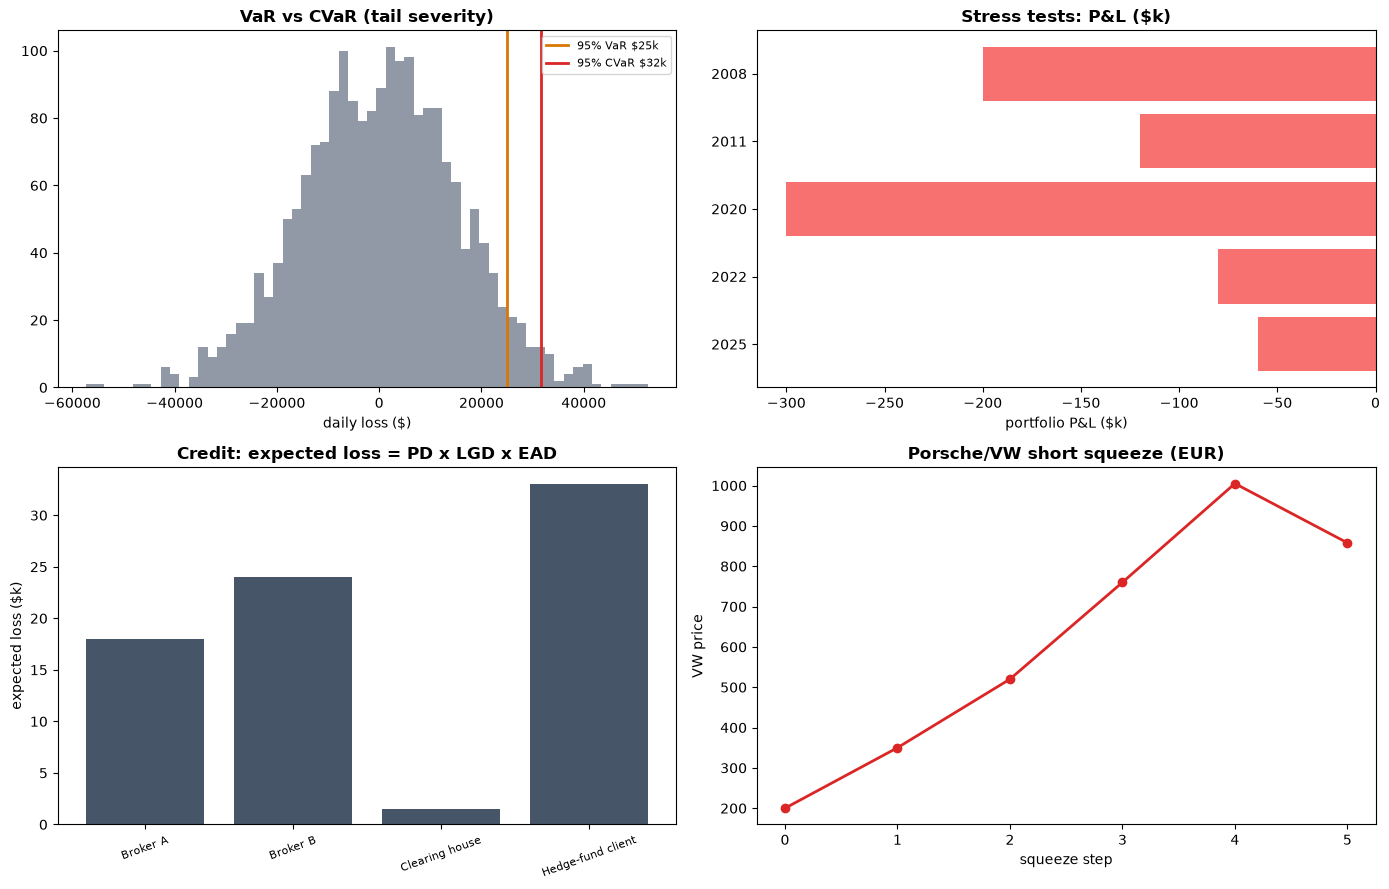

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
GR="#475569"; RD="#dc2626"; RD2="#f87171"; AM="#d97706"

# (1) VaR vs CVaR on the return distribution
ax[0,0].hist(losses, bins=60, color=GR, alpha=0.6)
ax[0,0].axvline(var_hist, color=AM, lw=2, label=f"95% VaR ${var_hist/1e3:.0f}k")
ax[0,0].axvline(cvar, color=RD, lw=2, label=f"95% CVaR ${cvar/1e3:.0f}k")
ax[0,0].set_title("VaR vs CVaR (tail severity)", fontweight="bold")
ax[0,0].set_xlabel("daily loss ($)"); ax[0,0].legend(fontsize=8)

# (2) stress tests
sv = list(stress.values()); sk = [k.split(" ")[0] for k in stress.keys()]
ax[0,1].barh(sk, [v*PV/1e3 for v in sv], color=RD2)
ax[0,1].set_title("Stress tests: P&L ($k)", fontweight="bold")
ax[0,1].set_xlabel("portfolio P&L ($k)"); ax[0,1].invert_yaxis()

# (3) expected loss by counterparty
ax[1,0].bar(book.counterparty, book.expected_loss/1e3, color=GR)
ax[1,0].set_title("Credit: expected loss = PD x LGD x EAD", fontweight="bold")
ax[1,0].set_ylabel("expected loss ($k)"); ax[1,0].tick_params(axis="x", rotation=20, labelsize=8)

# (4) VW short squeeze
ax[1,1].plot(px, "o-", color=RD, lw=2)
ax[1,1].set_title("Porsche/VW short squeeze (EUR)", fontweight="bold")
ax[1,1].set_xlabel("squeeze step"); ax[1,1].set_ylabel("VW price")

plt.tight_layout(); plt.savefig("chart_1_risk.png", dpi=115, bbox_inches="tight")
print("saved chart_1_risk.png")

## The one-paragraph version

Risk management is a **five-phase process**: build an **independent risk department** with veto power,
**identify** every source of risk (market, credit, financial, operational, liquidity, disaster),
**quantify** it (Greeks, what-if grids, and above all **VaR** — the 5th-percentile loss, via
historical / parametric / Monte Carlo — plus **CVaR** for the tail's average severity, **stress tests**
that replay 2008/COVID, and **PD × LGD × EAD** for credit), **set limits** (cash, geography, sector,
settlement, orders-per-day), and **design controls** that monitor in real time. The case studies are
the lesson: **Kerviel/Adoboli** (rogue traders → independent risk + mandatory leave), **LTCM**
(leverage + the 1998 Russian default → financial *and* liquidity risk at once), **Knight Capital** (one
stale server → **MD5 checksums**), **Credit Suisse / Hanmax / Deutsche Bank** (UI and data bugs →
confirmation, validation, and **stale-data timestamp** checks). For algos specifically, the controls
sit *inside the app before the gateway* — **heartbeats**, **stale-data** rejection, **garbled-book**
(ask &lt; bid) rejection, **fat-finger / price-range** bands, the **tick-by-tick order gate** (count
placed *plus in-flight* against a limit), **PnL-fluctuation** alerts, and **scalability** profiling
because nested loops turn $O(n)$ into $O(n^3)$. And the **Porsche/VW** squeeze explains why exchanges
cap derivative open interest against the free float. You don't have to make every mistake yourself —
that's the whole point.


---

# Additive source-backed continuation

The original notebook cells above are preserved. The first added cell only supplies a local SciPy fallback when SciPy is absent.


# PRM-01 resource addendum

This additive notebook preserves the original notebook and adds source-backed risk-control references from the lecture PDFs and transcript.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['prm01_source_pdf_inventory.csv','prm01_risk_process_control_matrix.csv','prm01_risk_taxonomy.csv','prm01_var_cvar_liquidity_reference.csv','prm01_credit_financial_regulatory_reference.csv','prm01_incident_control_map.csv','prm01_algo_pretrade_controls.csv','prm01_indian_exchange_controls.csv','prm01_var_cvar_liquidity_demo.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Source inventory and five-phase process

The source packet has lecture notes, a summary, and FAQs. The process moves from governance to real-time controls.

In [ ]:
pdfs = data['prm01_source_pdf_inventory.csv']
process = data['prm01_risk_process_control_matrix.csv']
print(pdfs[['file','pages','keyword_hits']].to_string(index=False))
print(process[['phase','control_artifact']].to_string(index=False))
assert len(process) == 5
assert process['phase'].str.contains('Design controls').any()

## 2. Risk taxonomy

The lecture separates market, credit, financial, operational, liquidity, regulatory, and disaster risks. Several examples are not price risk at all.

In [ ]:
taxonomy = data['prm01_risk_taxonomy.csv']
print(taxonomy[['risk_source','measurement','control']].to_string(index=False))
assert taxonomy['risk_source'].str.contains('Liquidity').any()
assert taxonomy['risk_source'].str.contains('Regulatory').any()

## 3. VaR, CVaR, stress, and liquidity-adjusted VaR

VaR is a threshold. CVaR is the average loss once the threshold is crossed. Liquidity-adjusted VaR adds the cost of actually exiting the position.

In [ ]:
var_ref = data['prm01_var_cvar_liquidity_reference.csv']
demo = data['prm01_var_cvar_liquidity_demo.csv']
print(var_ref[['method','implementation_control']].to_string(index=False))
print(demo.to_string(index=False))
assert var_ref['method'].str.contains('CVaR').any()
assert demo['liquidity_adjusted_var'].is_monotonic_increasing

## 4. Credit, financial, regulatory, and settlement risk

The lecture's key formulas are PD x LGD x EAD for expected credit loss and a funding-risk sensitivity for downgrade/rate shocks.

In [ ]:
credit = data['prm01_credit_financial_regulatory_reference.csv']
print(credit.to_string(index=False))
assert credit['lecture_formula'].str.contains('PD x LGD x EAD').any()
assert credit['topic'].str.contains('Settlement mismatch').any()

## 5. Incidents mapped to controls

The incidents are useful only if each one turns into a concrete control you can implement.

In [ ]:
inc = data['prm01_incident_control_map.csv']
print(inc[['incident','root_cause','control_added']].to_string(index=False))
assert inc['incident'].str.contains('Knight').any()
assert inc['control_added'].str.contains('MD5').any()

## 6. Algo pretrade gateway and exchange-style controls

These controls sit before the order reaches the exchange, and many match exchange-level safeguards.

In [ ]:
pre = data['prm01_algo_pretrade_controls.csv']
ind = data['prm01_indian_exchange_controls.csv']
print(pre[['control_area','reject_or_halt_condition']].to_string(index=False))
print(ind[['rule_area','system_control']].to_string(index=False))
assert pre['control_area'].str.contains('Order gate').any()
assert ind['rule_area'].str.contains('open interest', case=False).any()